/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2039/1231522772.py:3: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



GENERIC DEUTSCH ALGORITHM

Selected Function: balanced_x

Selected Oracle:
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

Complete Circuit:
     ┌───┐          ┌───┐
q_0: ┤ H ├───────■──┤ H ├
     ├───┤┌───┐┌─┴─┐└───┘
q_1: ┤ X ├┤ H ├┤ X ├─────
     └───┘└───┘└───┘     

MEASUREMENT RESULTS
Shots : 1000
0 count : 0
1 count : 1000
P(0) : 0.0000
P(1) : 1.0000

Deutsch Result : 1
Function Type : BALANCED


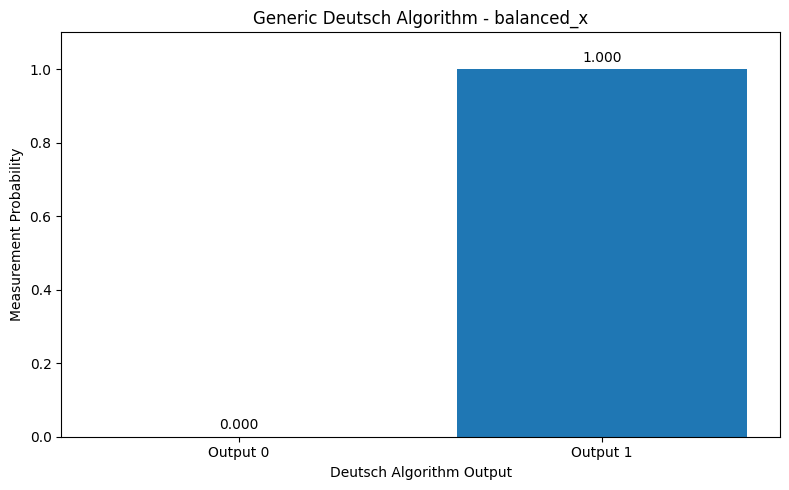

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

SHOTS = 1000

# ---------------------------------------------------------
# GENERIC ORACLE SELECTION
# ---------------------------------------------------------

def select_oracle(function_type):
    oracle = QuantumCircuit(2)

    if function_type == "constant_0":
        pass

    elif function_type == "constant_1":
        oracle.x(1)

    elif function_type == "balanced_x":
        oracle.cx(0, 1)

    elif function_type == "balanced_not_x":
        oracle.x(1)
        oracle.cx(0, 1)

    else:
        raise ValueError(
            "Unknown function type. Use constant_0, "
            "constant_1, balanced_x or balanced_not_x."
        )

    return oracle


# ---------------------------------------------------------
# RUN DEUTSCH ALGORITHM
# ---------------------------------------------------------

def run_deutsch(function_type):

    qc = QuantumCircuit(2)

    # Initial state |0>|1>
    qc.x(1)

    # Superposition
    qc.h(0)
    qc.h(1)

    # Dynamically selected oracle
    oracle = select_oracle(function_type)
    qc.compose(oracle, inplace=True)

    # Interference
    qc.h(0)

    # Statevector
    state = Statevector.from_instruction(qc)
    probabilities = state.probabilities()

    p0 = 0.0
    p1 = 0.0

    for index, probability in enumerate(probabilities):

        bit = format(index, "02b")
        q0 = bit[-1]

        if q0 == "0":
            p0 += probability
        else:
            p1 += probability

    # Measurements
    rng = np.random.default_rng(42)

    samples = rng.choice(
        [0, 1],
        size=SHOTS,
        p=[p0, p1]
    )

    count_0 = int(np.sum(samples == 0))
    count_1 = int(np.sum(samples == 1))

    return qc, oracle, count_0, count_1


# ---------------------------------------------------------
# SELECT FUNCTION
# ---------------------------------------------------------

FUNCTION_TYPE = "balanced_x"

qc, oracle, count_0, count_1 = run_deutsch(
    FUNCTION_TYPE
)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\nGENERIC DEUTSCH ALGORITHM")
print("=" * 70)

print(f"\nSelected Function: {FUNCTION_TYPE}")

print("\nSelected Oracle:")
print(oracle.draw())

print("\nComplete Circuit:")
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("=" * 70)

print(f"Shots : {SHOTS}")
print(f"0 count : {count_0}")
print(f"1 count : {count_1}")

p0 = count_0 / SHOTS
p1 = count_1 / SHOTS

print(f"P(0) : {p0:.4f}")
print(f"P(1) : {p1:.4f}")

if count_0 > count_1:
    result = "CONSTANT"
    answer = 0
else:
    result = "BALANCED"
    answer = 1

print(f"\nDeutsch Result : {answer}")
print(f"Function Type : {result}")

# ---------------------------------------------------------
# GRAPH
# ---------------------------------------------------------

labels = ["Output 0", "Output 1"]
values = [p0, p1]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Measurement Probability")
plt.xlabel("Deutsch Algorithm Output")
plt.title(
    f"Generic Deutsch Algorithm - {FUNCTION_TYPE}"
)

plt.ylim(0, 1.1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()